In [3]:
import os
os.chdir(r"C:\Users\Pc\Desktop\오픈소스 기말 프로젝트")
os.getcwd()

'C:\\Users\\Pc\\Desktop\\오픈소스 기말 프로젝트'

In [4]:
import pandas as pd

# 도심권 권역코드 숫자 
DOSIM_CODE = 100   

#1. 대기오염 데이터(시간평균)
def load_poll(csv_path):
    poll = pd.read_csv(csv_path, encoding="cp949", encoding_errors="ignore")
    #    0: 측정일시
    #    1: 권역코드
    #    5: 미세먼지 1시간
    #    7: 초미세먼지
    #    8: 오존 농도
    #    9: 이산화질소농도
    #   10: 일산화탄소농도
    #   11: 아황산가스농도
    poll = poll.iloc[:, [0, 1, 5, 7, 8, 9, 10, 11]].copy()
    
    #컬럼 이름 통일
    poll.columns = ["datetime","region_code", "PM10", "PM25", "O3", "NO2", "CO", "SO2"]
    
    #datetime 문자열에서 앞뒤 따옴표/공백 제거
    poll["datetime"] = poll["datetime"].astype(str).str.replace('"', "").str.strip()
    
    #"202007010000" 형식 → datetime으로 변환
    poll["datetime"] = pd.to_datetime( poll["datetime"], format="%Y%m%d%H%M", errors="coerce" )
    
    #변환 실패한 행 제거
    poll = poll.dropna(subset=["datetime"])
    
    #도심권만으로 영역 제한.
    poll = poll[poll["region_code"] == DOSIM_CODE]

    return poll

poll_files = [
    "서울시_기간별_시간평균_대기환경_정보_2022.csv",
    "서울시_기간별_시간평균_대기환경_정보_2023.csv",
    "서울시_기간별_시간평균_대기환경_정보_2024.csv"]

poll_list = [load_poll(path) for path in poll_files] # 여러해 파일들을 리스트로 저장
poll_all = pd.concat(poll_list,ignore_index=True)    # poll_list 한번에 합친 버전
poll_hourly = poll_all.groupby("datetime").mean(numeric_only=True).reset_index()  #도심권내 여러 측정소 평균


#2. 기상 데이터(정각 관측 -> 시간평균)
def load_weather(csv_path):
    #전체를 읽되, 인코딩은 latin1로 강제 
    weather = pd.read_csv(csv_path, encoding="latin1")

    # 필요한 컬럼만 인덱스로 선택
    #    2: 일시 
    #    3: 기온
    #    9: 습도
    #    5: 풍속
    weather = weather.iloc[:, [2, 3, 9, 5]].copy()

    #컬럼 이름 통일
    weather.columns = ["datetime", "temp", "humidity", "wind"]

    #datetime 형식으로 변환
    weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce" )
    
    #변환 실패한 행 제거
    weather = weather.dropna(subset=["datetime"])

    return weather

weather_files = [
    "OBS_ASOS_TIM_22.csv",
    "OBS_ASOS_TIM_23.csv",
    "OBS_ASOS_TIM_24.csv"]

weather_list = [load_weather(path) for path in weather_files]
weather_all = pd.concat(weather_list, ignore_index=True)

# 기상 데이터 -> 시간 단위 평균 
weather_all["datetime_hour"] = weather_all["datetime"].dt.floor("h")
weather_hourly = (weather_all.groupby("datetime_hour").mean(numeric_only=True).reset_index().rename(columns={"datetime_hour": "datetime"}))



#3. 오존 주의보: 도심권만 + 발령/해제 시각
def load_alert(xlsx_path):
    alert = pd.read_excel(xlsx_path,header=5)
    alert = alert[alert["권역"]=="도심권"].copy()
    alert["start"] = pd.to_datetime(alert["발령시간"])
    alert["end"] = pd.to_datetime(alert["해제시간"])
    return alert
    
alert_files = [
    "주의보_경보발령내역(22).xlsx",
    "주의보_경보발령내역(23).xlsx",
    "주의보_경보발령내역(24).xlsx"]

alert_list = [load_alert(path) for path in alert_files]
alert_all = pd.concat(alert_list, ignore_index=True)




#최종 df 생성하기
poll_all["datetime"]=pd.to_datetime(poll_all["datetime"]) #도심권 전체 대기오염 데이터 (측정소별 원본)
weather_hourly["datetime"] = pd.to_datetime(weather_hourly["datetime"]) #시간 단위 평균 기상 데이터

df = poll_hourly.merge(weather_hourly, on="datetime", how="inner") #poll_hourly와 weather_hourly 병합

def is_alert(dt):   #오존 주의보 여부를 시간별로 True/False로 표시하는 함수
    return any((alert_all["start"] <= dt) & (alert_all["end"] >= dt))   # dt 시각이 발령(start) ≤ dt ≤ 해제(end) 구간 안에 있으면 True

df["alert"] = df["datetime"].apply(is_alert)  # df에 alert 컬럼 생성 → 각 시간대(datetime)가 주의보 기간인지 아닌지를 기록



print(df.shape)          # 최종 분석용 데이터(잘 만들어졌는지 확인용)
print(alert_all.shape)   # 경보 기간 데이터
print(weather_hourly.shape) # 시간별 기상 데이터
print(poll_hourly.shape)    # 도심권 시간별 평균 오염 데이터


print("=== 최종 데이터프레임(df) ===")
df.head() #test용



(17838, 12)
(33, 8)
(17838, 4)
(26304, 8)
=== 최종 데이터프레임(df) ===


,datetime,region_code,PM10,PM25,O3,NO2,CO,SO2,temp,humidity,wind,alert
0,2022-01-01 01:00:00,100.0,24.000000,11.666667,0.020667,0.020000,0.400000,0.003000,-9.2,42.0,1.8,False
1,2022-01-01 02:00:00,100.0,21.000000,10.000000,0.022000,0.019000,0.400000,0.003000,-9.5,43.0,1.2,False
2,2022-01-01 03:00:00,100.0,20.000000,10.333333,0.016333,0.025000,0.433333,0.002667,-9.3,46.0,1.4,False
3,2022-01-01 04:00:00,100.0,19.333333,10.000000,0.012000,0.029000,0.466667,0.002667,-9.6,48.0,1.7,False
4,2022-01-01 05:00:00,100.0,21.666667,12.666667,0.008000,0.034333,0.466667,0.002667,-9.7,51.0,0.8,False


In [43]:
df.to_csv("final_df.csv", index=False, encoding="utf-8-sig") #분석용 데이터 파일 추출


In [5]:
# 오존 농도가 높아지는 패턴 분석

#고농도일 vs 보통날 비교
high_ozone = df[df["alert"]== True]
normal = df[df["alert"] == False]

cols = [ "PM10", "PM25", "O3", "NO2", "CO", "SO2", "temp", "humidity", "wind"]

comparison = pd.DataFrame({ "High ozone days" : high_ozone[cols].mean(), "Normal days" : normal[cols].mean() })
comparison["Diff (High - Normal)"] = comparison["High ozone days"] - comparison["Normal days"]


comparison


,High ozone days,Normal days,Diff (High - Normal)
PM10,54.377451,33.846567,20.530884
PM25,41.036765,19.513684,21.523081
O3,0.116784,0.030554,0.086230
NO2,0.019358,0.021833,-0.002475
CO,0.502549,0.458208,0.044341
SO2,0.003657,0.003099,0.000558
temp,30.747059,13.695741,17.051317
humidity,56.308824,65.580353,-9.271530
wind,2.720588,2.325162,0.395426


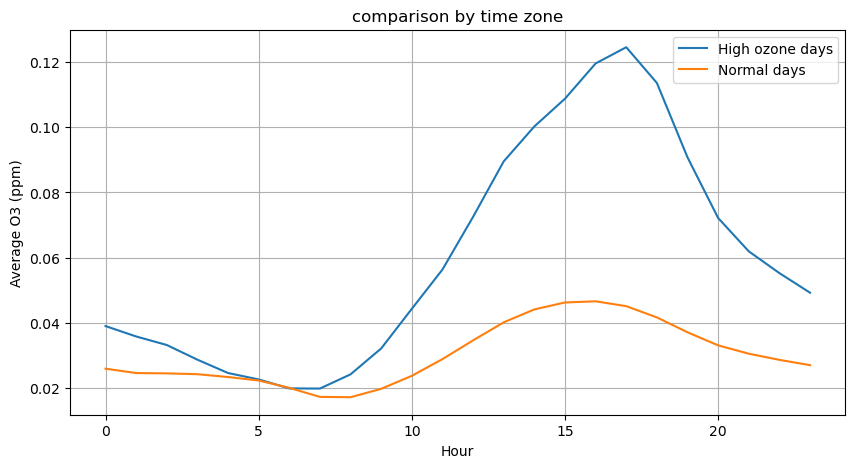

In [7]:
#주의보가 뜬 날 전체 vs 정상일 전체 그래프 (오존이 언제 가장 높아지는지)

import pandas as pd
import matplotlib.pyplot as plt

df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour

alert_days = df.loc[df["alert"], "date"].unique()
high_day = df[df["date"].isin(alert_days)] 

all_days = df["date"].unique()
normal_days = [ d for d in all_days if d not in alert_days]
normal_day = df[df["date"].isin(normal_days)]

high_hour = high_day.groupby("hour")["O3"].mean()
normal_hour = normal_day.groupby("hour")["O3"].mean()

hours = range(24)
high_hour = high_hour.reindex(hours)
normal_hour = normal_hour.reindex(hours)

plt.figure(figsize=(10,5))
plt.plot(hours, high_hour.values, label = "High ozone days")
plt.plot(hours, normal_hour.values, label = "Normal days")
plt.xlabel("Hour")
plt.ylabel("Average O3 (ppm)")
plt.title("comparison by time zone")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
#계절별 분석

df["month"] = df["datetime"].dt.month

mean = df.groupby("month")["O3"].mean()
median = df.groupby("month")["O3"].median()
std = df.groupby("month")["O3"].std()

monthly_stats = pd.DataFrame({"mean": mean,"median": median,"std": std})


monthly_stats

,mean,median,std
month,,,
1,0.016228,0.016333,0.010900
2,0.025262,0.028050,0.013076
3,0.031959,0.032933,0.017145
4,0.040355,0.039967,0.017304
5,0.046177,0.044400,0.020753
6,0.042940,0.039667,0.022257
7,0.038125,0.034333,0.024521
8,0.033288,0.028000,0.020845
9,0.032682,0.030583,0.018641


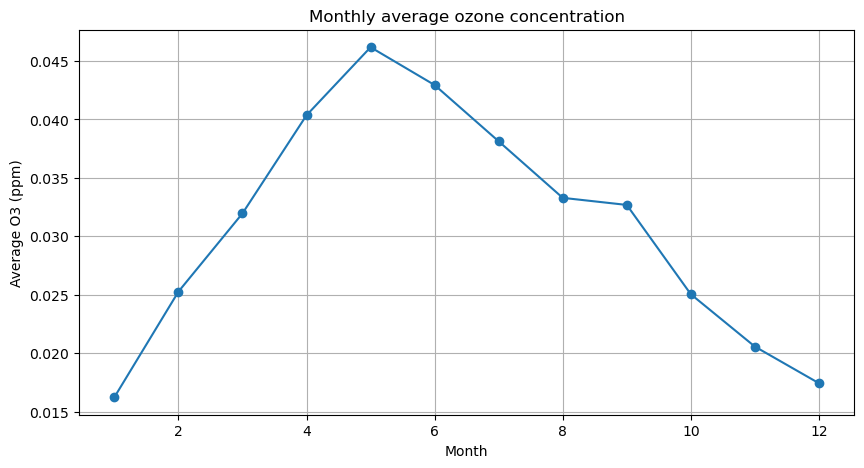

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.plot(monthly_stats.index, monthly_stats["mean"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average O3 (ppm)")
plt.title("Monthly average ozone concentration")
plt.grid(True)
plt.show()

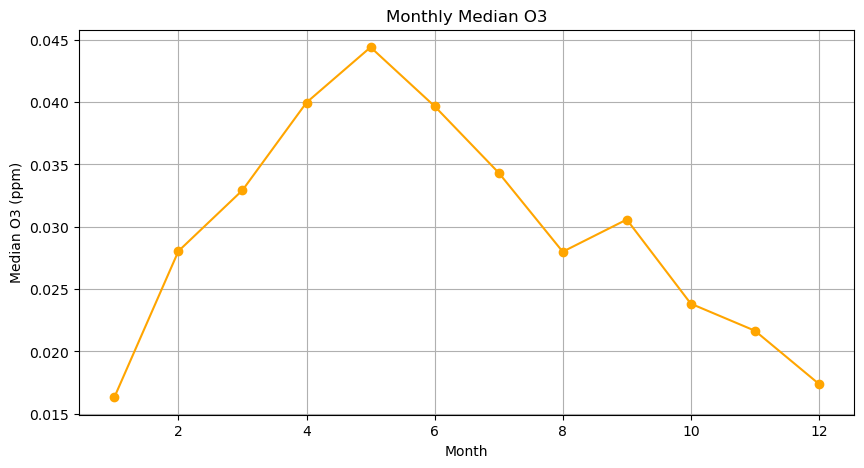

In [10]:
#월별 중앙값 그래프

plt.figure(figsize=(10,5))
plt.plot(monthly_stats.index, monthly_stats["median"], marker="o", color="orange")
plt.xlabel("Month")
plt.ylabel("Median O3 (ppm)")
plt.title("Monthly Median O3")
plt.grid(True)
plt.show()


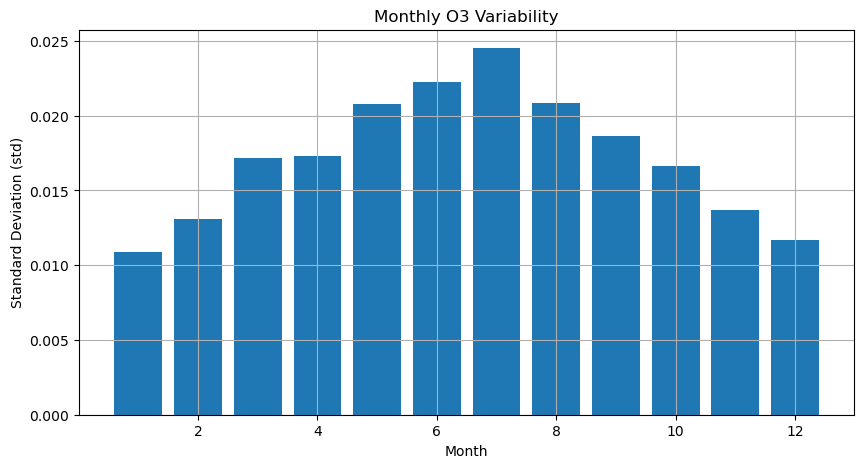

In [11]:
#월별 변동성 분석

plt.figure(figsize=(10,5))
plt.bar(monthly_stats.index, monthly_stats["std"])
plt.xlabel("Month")
plt.ylabel("Standard Deviation (std)")  #오존 농도의 변동성(표준편차)
plt.title("Monthly O3 Variability")
plt.grid(True)
plt.show()


In [17]:
#고농도일 직전의 대기 변화

df = df.sort_values("datetime")   #날짜 기준으로 정렬
df["date"] = df["datetime"].dt.date

alert_days = df.loc[df["alert"], "date"].unique() #고농도일 리스트 선택

daily = df.groupby("date")[cols].mean()
daily_diff = daily.diff()  #전날 대비 얼마나 증가, 감소했는지

high_prev = daily_diff.loc[alert_days]
high_prev  #고농도일 ‘전날 대비’ 얼마나 변했는지



,PM10,PM25,O3,NO2,CO,SO2,temp,humidity,wind
date,,,,,,,,,
2022-05-23,26.500000,17.222222,0.014167,0.007292,0.145833,0.000583,2.800000,-6.291667,-0.045833
2022-05-28,9.833333,8.722222,0.006403,0.006681,0.111111,0.001486,2.137500,-5.958333,-0.679167
2022-06-03,10.277778,8.388889,0.016750,0.003549,0.118056,-0.000132,2.712500,-2.208333,-0.520833
2022-07-05,-2.368056,-2.111111,0.014889,0.002986,0.000000,-0.000111,-0.012500,1.958333,-0.075000
2022-07-10,17.145833,13.159722,0.018778,0.004708,0.119444,0.000653,2.250000,-12.458333,-0.091667
2022-07-26,12.270833,10.784722,0.027250,0.004611,0.042361,0.000118,1.400000,-3.500000,-0.108333
2022-08-12,10.138889,5.833333,0.019500,-0.003944,-0.070833,0.000000,1.991667,-13.291667,-0.033333
2022-09-29,26.027778,23.819444,0.023847,-0.005056,0.105556,0.000236,0.133333,3.791667,-0.404167
2023-05-16,21.465278,12.333333,0.019939,0.001077,0.073611,0.000416,3.504167,-1.666667,0.262500


In [19]:
prev_change_mean = high_prev.mean()
prev_change_mean   #평균 변화패턴 계산

PM10        11.592882
PM25         9.122830
O3           0.015021
NO2          0.002218
CO           0.048828
SO2          0.000249
temp         1.646615
humidity    -4.213542
wind        -0.061979
dtype: float64

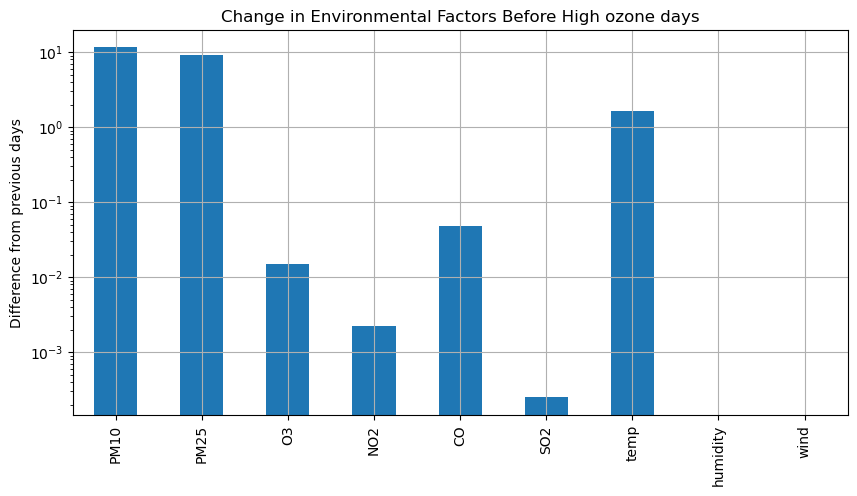

In [22]:
prev_change_mean.plot(kind="bar",figsize=(10,5))
plt.title("Change in Environmental Factors Before High ozone days")
plt.ylabel("Difference from previous days")
plt.yscale("log")
plt.grid(True)
plt.show()

In [27]:
#고농도 당일의 대기환경이 어떨 때 오존 농도가 높게 나타나는지

high_days_daily = daily.loc[alert_days] #고농도 당일의 평균값
high_days_daily 

,PM10,PM25,O3,NO2,CO,SO2,temp,humidity,wind
date,,,,,,,,,
2022-05-23,61.888889,41.972222,0.073542,0.017361,0.495833,0.003722,22.850000,64.750000,2.383333
2022-05-28,31.541667,19.222222,0.059931,0.019069,0.433333,0.004458,22.091667,56.125000,2.725000
2022-06-03,36.166667,23.847222,0.070597,0.019778,0.470833,0.003278,24.095833,63.875000,2.004167
2022-07-05,31.750000,25.638889,0.047083,0.021097,0.338889,0.003139,29.208333,73.916667,1.637500
2022-07-10,39.166667,29.666667,0.060750,0.019028,0.506944,0.003556,28.995833,70.250000,1.562500
2022-07-26,30.486111,20.680556,0.057667,0.018000,0.409722,0.003083,28.779167,72.250000,1.795833
2022-08-12,22.555556,14.194444,0.051375,0.018097,0.329167,0.003125,26.904167,74.791667,1.691667
2022-09-29,56.513889,41.500000,0.049944,0.028736,0.609722,0.003361,20.508333,73.416667,1.487500
2023-05-16,54.763889,32.569444,0.074540,0.021983,0.496250,0.003611,23.787500,53.750000,2.537500


In [29]:
comp = pd.DataFrame({
    "High ozone days": high_days_daily.mean(),
    "Normal days" : daily.drop(alert_days).mean()
})

comp  #고농도일과 정상일 비교(분포 차이)

,High ozone days,Normal days
PM10,40.138021,31.980090
PM25,28.828125,18.843103
O3,0.059967,0.029203
NO2,0.020131,0.021598
CO,0.473559,0.449824
SO2,0.003371,0.002980
temp,26.692969,13.904826
humidity,68.023438,65.653747
wind,1.949740,2.326874


In [30]:
trigger = high_days_daily.quantile(0.75)
trigger   #고농도일의 상위 25퍼 기준

PM10        52.842014
PM25        34.354167
O3           0.067423
NO2          0.021281
CO           0.506215
SO2          0.003516
temp        29.046875
humidity    72.572917
wind         2.067708
Name: 0.75, dtype: float64

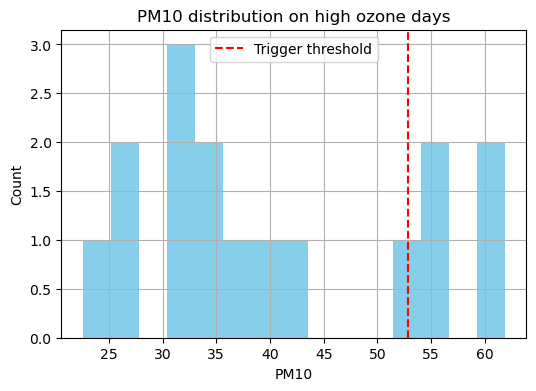

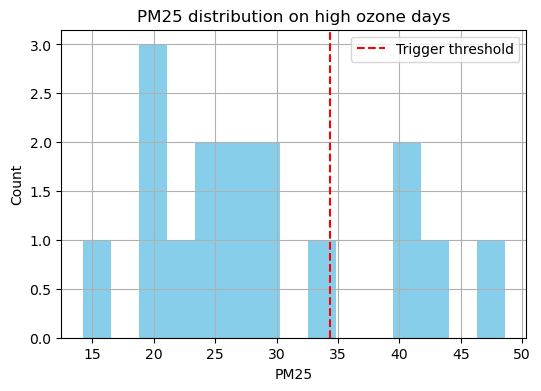

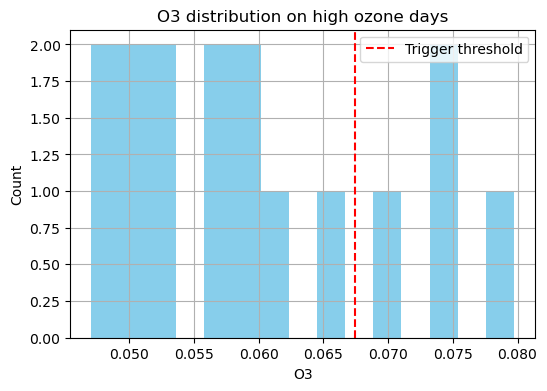

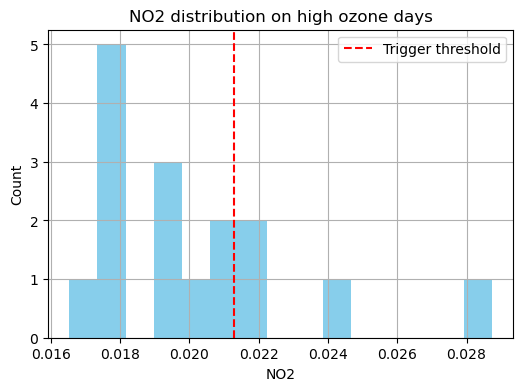

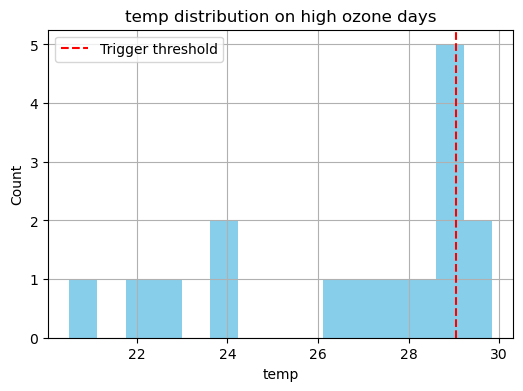

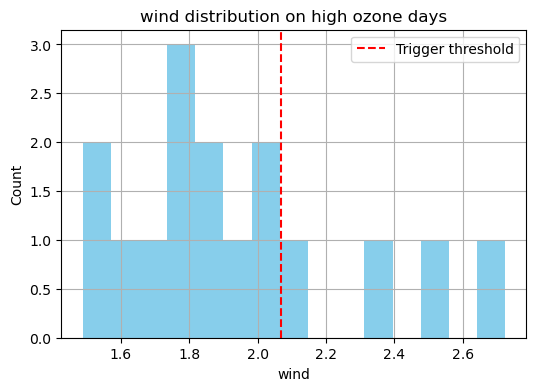

In [35]:
import matplotlib.pyplot as plt

for col in ["PM10", "PM25", "O3","NO2", "temp", "wind"]:
    plt.figure(figsize=(6,4))
    plt.hist(high_days_daily[col], bins=15, color='skyblue')
    plt.axvline(trigger[col], color = 'red', linestyle='--', label = 'Trigger threshold') #trigger threshold 넘으면 오존 고농도 발생 가능성 급상승
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"{col} distribution on high ozone days")
    plt.legend()
    plt.grid(True)
    plt.show()

In [55]:
#머신러닝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_df.csv')

df.columns = ["datetime", "region_code", "PM10", "PM25", "O3", "NO2", "CO", "SO2", "temp", "humidity", "wind", "alert"]

#풍속 결측치 처리
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = df["datetime"].dt.date
df["wind"] = df.groupby("date")["wind"].transform(lambda x: x.fillna(x.mean()))

#분석에 활용할 열(속성) 선택(기온, 미세먼지, 초미세먼지, 풍속, 이산화질소, 오존 농도)
ndf = df[['temp','PM10', 'PM25', 'wind', 'NO2', 'O3']]

#데이터셋 구분 - 훈련용 vs 검증용

#속성(변수) 선택
x = ndf[['temp','PM10', 'PM25', 'wind', 'NO2']]
y = ndf['O3']

#훈련용 데이터와 검증용 데이터로 구분
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 10)

print('훈련 데이터: ', x_train.shape)
print('검증 데이터: ', x_test.shape)



훈련 데이터:  (12486, 5)
검증 데이터:  (5352, 5)


In [62]:
#다중회귀분석 모형 - sklearn 사용

#sklearn 라이브러리에서 선형회귀분석 모듈 가져오기
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

#훈련용 데이터를 가지고 모형 학습
lr.fit(x_train,y_train)

#학습을 마친 모형에 검증 데이터를 적용하여 결정계수(R-제곱) 계산
r_square = lr.score(x_test, y_test)
print(r_square)
print('\n')

#회귀식의 기울기
print('x 변수의 계수 a:', lr.coef_)
print('\n')

#회귀식의 y절편
print('상수항 b:', lr.intercept_)


0.49840700077850686


x 변수의 계수 a: [ 6.54400208e-04  4.27050919e-05  4.99297246e-04  2.74349621e-03
 -8.42548771e-01]


상수항 b: 0.022631164377311636


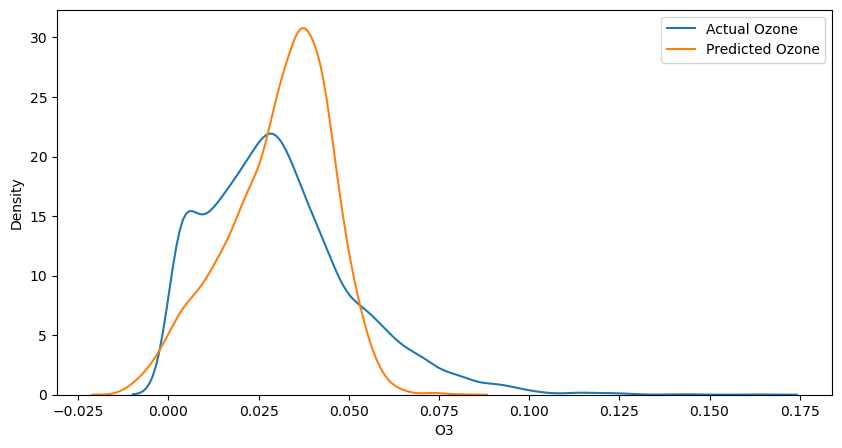

In [70]:
#그래프로 출력

y_hat = lr.predict(x_test)

plt.figure(figsize=(10, 5))
ax1 = sns.kdeplot(y_test, label = "Actual Ozone")  #실제 오존값
ax2 = sns.kdeplot(y_hat, label = "Predicted Ozone", ax=ax1)  #예측 오존

plt.legend()
plt.show()